## Prepare the notebook

In [155]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
import warnings
warnings.filterwarnings('ignore')

In [156]:
# Load the data
df = pd.read_csv("D:/Programming/Data_science/Codveda-Internship/Level 1/Task 2/processed_real_estate.csv")

df

,name,sqm,year_built,Price(EGP),Price/Sqm,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,...,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is FloorNumber outlier
0,Alamain (Latin District),92.86,2025,6594000,71010.1228,1,1,0,0,1,...,0,0,0,4.531093,15.701671,11.170578,False,False,False,False
1,Beachfront Tower - B1,398.00,2025,66104000,166090.4523,0,0,0,0,1,...,0,0,0,5.986452,18.006740,12.020288,False,False,True,False
2,PODIA,93.00,2025,12824000,137892.4731,0,1,1,0,1,...,1,0,0,4.532599,16.366829,11.834229,False,False,False,True
3,Mazarine Apartment,252.00,2025,12857000,51019.8413,1,1,0,0,0,...,0,0,0,5.529429,16.369399,10.839970,False,False,False,False
4,Alamain (Latin District),209.42,2025,8721000,41643.5870,1,1,0,0,1,...,0,0,0,5.344342,15.981244,10.636903,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,Zahya,410.00,2024,11028000,26897.5610,1,1,0,1,0,...,0,0,0,6.016157,16.215948,10.199791,False,False,False,False
876,Zahya,410.00,2024,10542000,25712.1951,1,1,0,1,0,...,0,0,0,6.016157,16.170878,10.154721,False,False,False,False
877,Zahya,504.00,2024,11890000,23591.2698,1,1,0,1,0,...,0,0,0,6.222576,16.291208,10.068632,False,False,False,False
878,Zahya,345.00,2024,10209000,29591.3043,1,1,0,1,0,...,0,0,0,5.843544,16.138780,10.295236,False,False,False,False


## The chart of years

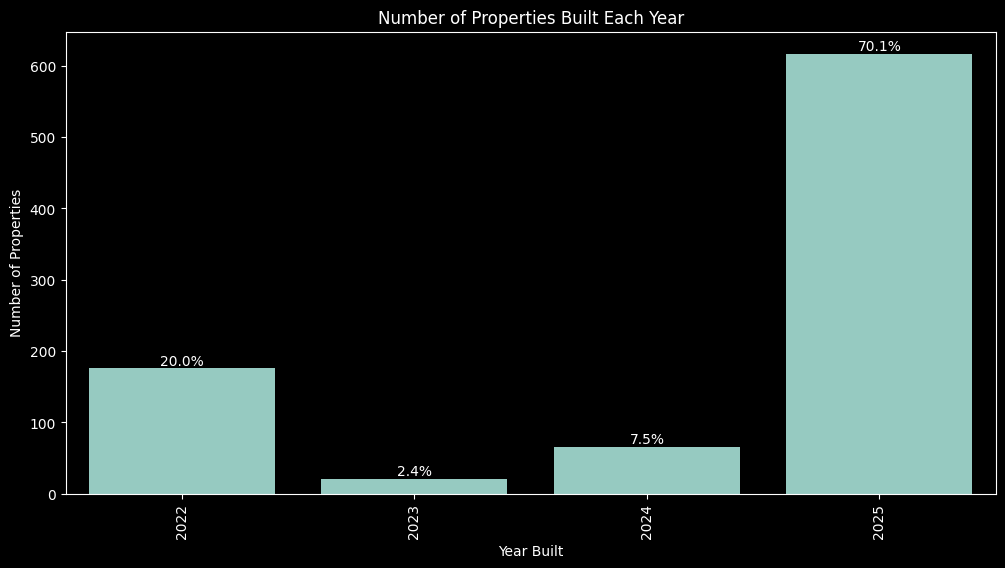

In [157]:
df["year_built"] = df["year_built"].astype(str) # convert the type of it to string for better visualization
plt.figure(figsize=(12, 6)) # set the figure size
order = df["year_built"].sort_values().unique() # get the unique years in sorted order
ax = sns.countplot(data=df, x="year_built", order=order) # create the count plot
plt.xticks(rotation=90) # rotate the x labels for better readability
# Add title and labels
plt.title("Number of Properties Built Each Year")
plt.xlabel("Year Built")
plt.ylabel("Number of Properties")
# show the percentages on top of the bars
total = df.shape[0]
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', labels=[f'{(v.get_height()/total)*100:.1f}%' for v in container]) # show the percentages

- We have imbalanced data in terms of years built.
- Most of the collected properties were built in 2025.
- Exclude 2023 from the time series data due to small data amount

In [158]:
year_2023 = df[df["year_built"] == "2023"]
df.drop(year_2023.index, inplace=True)
df[:10]

,name,sqm,year_built,Price(EGP),Price/Sqm,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,...,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is FloorNumber outlier
0,Alamain (Latin District),92.86,2025,6594000,71010.1228,1,1,0,0,1,...,0,0,0,4.531093,15.701671,11.170578,False,False,False,False
1,Beachfront Tower - B1,398.00,2025,66104000,166090.4523,0,0,0,0,1,...,0,0,0,5.986452,18.006740,12.020288,False,False,True,False
2,PODIA,93.00,2025,12824000,137892.4731,0,1,1,0,1,...,1,0,0,4.532599,16.366829,11.834229,False,False,False,True
3,Mazarine Apartment,252.00,2025,12857000,51019.8413,1,1,0,0,0,...,0,0,0,5.529429,16.369399,10.839970,False,False,False,False
4,Alamain (Latin District),209.42,2025,8721000,41643.5870,1,1,0,0,1,...,0,0,0,5.344342,15.981244,10.636903,False,False,False,False
5,Latin City,139.00,2025,6688000,48115.1079,0,1,0,0,1,...,0,0,0,4.934474,15.715825,10.781352,False,False,False,False
6,Downtown commercial,272.00,2025,32696000,120205.8824,1,1,0,0,1,...,0,0,1,5.605802,17.302763,11.696961,False,False,False,False
7,Beachfront Tower - B1,221.00,2025,28507000,128990.9502,0,0,0,0,1,...,0,0,0,5.398163,17.165660,11.767498,False,False,False,True
8,Downtown commercial,319.00,2025,36428000,114194.3574,1,1,0,0,1,...,0,0,1,5.765191,17.410848,11.645657,False,False,True,False
9,Downtown Extension,173.00,2022,8368000,48369.9422,1,1,0,1,1,...,0,0,0,5.153292,15.939925,10.786634,False,False,False,False


In [159]:
df[-10:]

,name,sqm,year_built,Price(EGP),Price/Sqm,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,...,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is FloorNumber outlier
867,Zahya,504.0,2024,12393000,24589.2857,1,1,0,1,0,...,0,0,0,6.222576,16.332642,10.110066,False,False,False,False
868,Zahya,410.0,2024,10538000,25702.4390,1,1,0,1,0,...,0,0,0,6.016157,16.170498,10.154341,False,False,False,False
869,Zahya,609.8,2024,17616000,28888.1601,1,1,0,1,0,...,0,1,0,6.413131,16.684318,10.271187,False,True,False,False
870,Zahya,498.0,2024,12192000,24481.9277,1,1,0,1,0,...,0,0,0,6.210600,16.316291,10.105690,False,False,False,False
873,Zahya,892.0,2024,22026000,24692.8251,1,1,0,1,0,...,0,1,0,6.793466,16.907734,10.114268,False,True,False,False
874,Zahya,325.0,2024,11375000,35000.0000,1,1,0,1,0,...,0,0,0,5.783825,16.246929,10.463103,False,False,False,False
875,Zahya,410.0,2024,11028000,26897.5610,1,1,0,1,0,...,0,0,0,6.016157,16.215948,10.199791,False,False,False,False
876,Zahya,410.0,2024,10542000,25712.1951,1,1,0,1,0,...,0,0,0,6.016157,16.170878,10.154721,False,False,False,False
877,Zahya,504.0,2024,11890000,23591.2698,1,1,0,1,0,...,0,0,0,6.222576,16.291208,10.068632,False,False,False,False
878,Zahya,345.0,2024,10209000,29591.3043,1,1,0,1,0,...,0,0,0,5.843544,16.138780,10.295236,False,False,False,False


## Model selection

### ADF test to test stationarity

In [160]:
### Pick y or the time series data
y = df["log(price/sqm)"]

print("The first 5 rows", y.head())
print("The last 5 rows", y.tail())

The first 5 rows 0    11.170578
1    12.020288
2    11.834229
3    10.839970
4    10.636903
Name: log(price/sqm), dtype: float64
The last 5 rows 874    10.463103
875    10.199791
876    10.154721
877    10.068632
878    10.295236
Name: log(price/sqm), dtype: float64


In [161]:
# Perform adf test for stationarity 
adfuller(y)

(np.float64(-29.07409783267709),
 0.0,
 0,
 858,
 {'1%': np.float64(-3.4379944895149097),
  '5%': np.float64(-2.864914462846141),
  '10%': np.float64(-2.5685668227188505)},
 np.float64(1657.7484782661822))

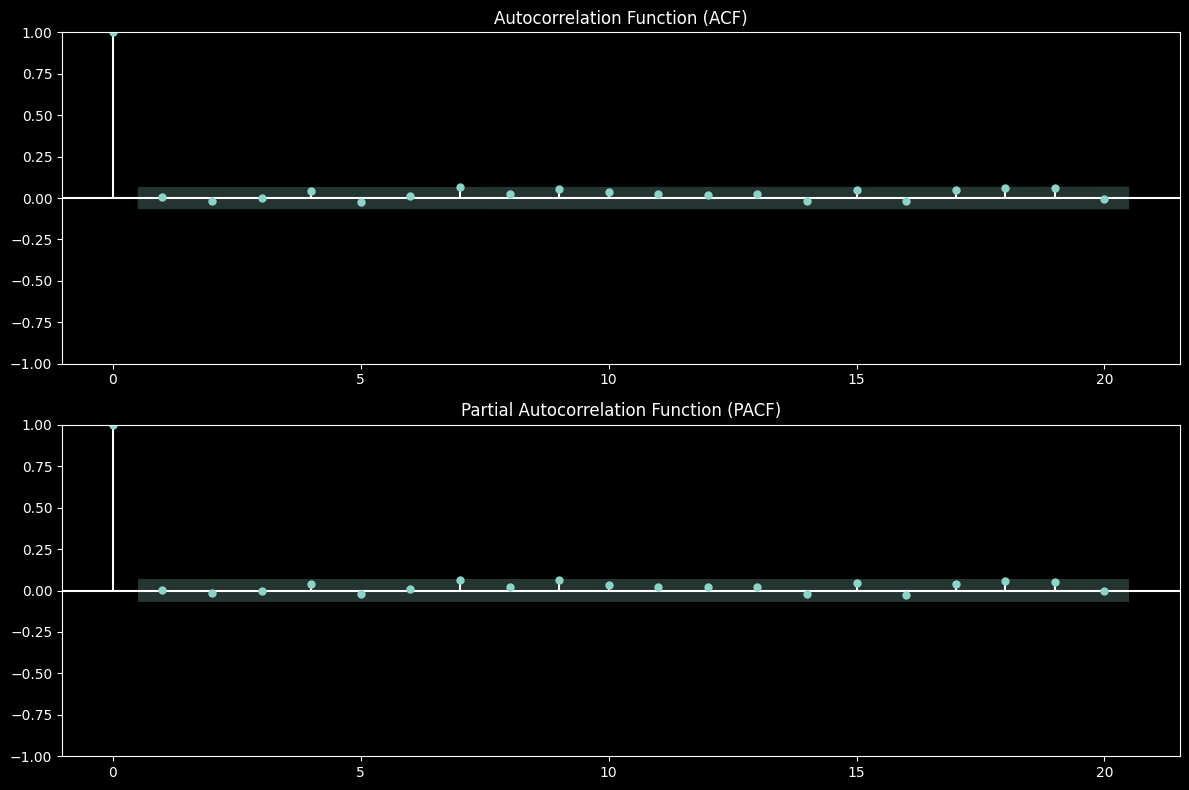

In [162]:
## See ACF, PACF charts 
def ACF_PACF_Charts(time_series, max_lags = 20):
    """This function plot the ACF, and PACF charts

    Args:
        time_series (array_like): the time series data
        max_lags (int, 20): Max number of lags. Default to 20
    """
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot the ACF
    plot_acf(time_series, ax=ax1, lags=max_lags) # 'lags' sets the maximum number of lags to display
    ax1.set_title("Autocorrelation Function (ACF)")

    # Plot the PACF
    plot_pacf(x=time_series, ax=ax2, lags=max_lags, method='ywm') # 'method' is required for plot_pacf
    ax2.set_title("Partial Autocorrelation Function (PACF)")

    plt.tight_layout()
    plt.show()
ACF_PACF_Charts(y)

- log(price/sqm) is white noise, so no model required for it

### Try the differences of log(price/sqm)

(np.float64(-11.438060978752281), np.float64(6.276551410790615e-21), 21, 836, {'1%': np.float64(-3.4381962830171444), '5%': np.float64(-2.8650034233058093), '10%': np.float64(-2.568614210583549)}, np.float64(1723.3854848139617))


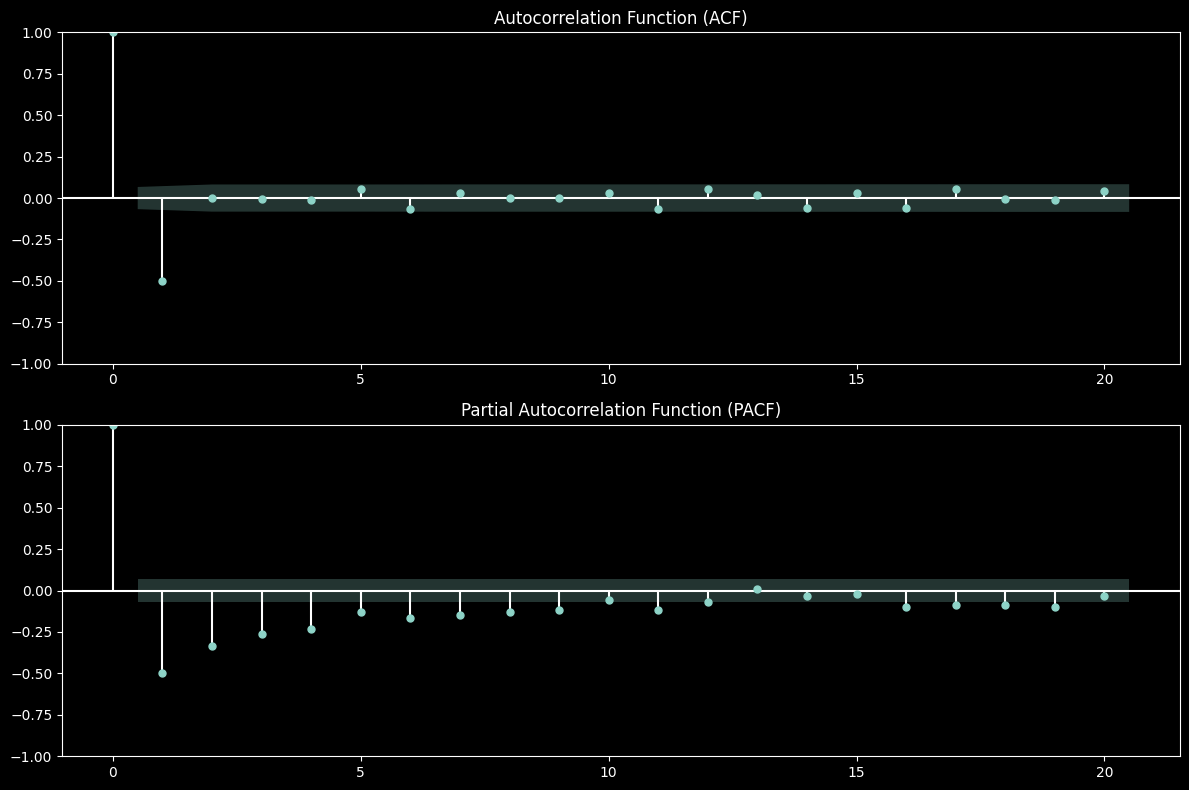

In [163]:
y_1 = df["log(price)"].diff(1).dropna() # y(-1)

print(adfuller(y_1))
ACF_PACF_Charts(y_1)

- After trying many models the best option is p = 0, d = 1, and q = 1

In [164]:
new_order = (0, 1, 1) # the new order
new_model = ARIMA(y, order=new_order).fit() # The new model

print(new_model.summary()) # Model summary

                               SARIMAX Results                                
Dep. Variable:         log(price/sqm)   No. Observations:                  859
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -843.374
Date:                Wed, 10 Dec 2025   AIC                           1690.747
Time:                        22:45:07   BIC                           1700.256
Sample:                             0   HQIC                          1694.388
                                - 859                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9778      0.011    -89.001      0.000      -0.999      -0.956
sigma2         0.4166      0.019     22.096      0.000       0.380       0.454
Ljung-Box (L1) (Q):                   1.09   Jarque-